  Population mean  (mu)    = 64.96
  Population SD    (sigma) = 12.02
SAMPLE      (n = 50)
  Sample mean      (x-bar) = 65.70
  Sample SD        (s)     = 12.67
Sampling error (x-bar - mu) = 0.74

Means of 5 different random samples of size 50:
  Sample 1: mean = 64.14
  Sample 2: mean = 65.54
  Sample 3: mean = 64.92
  Sample 4: mean = 65.02
  Sample 5: mean = 64.74


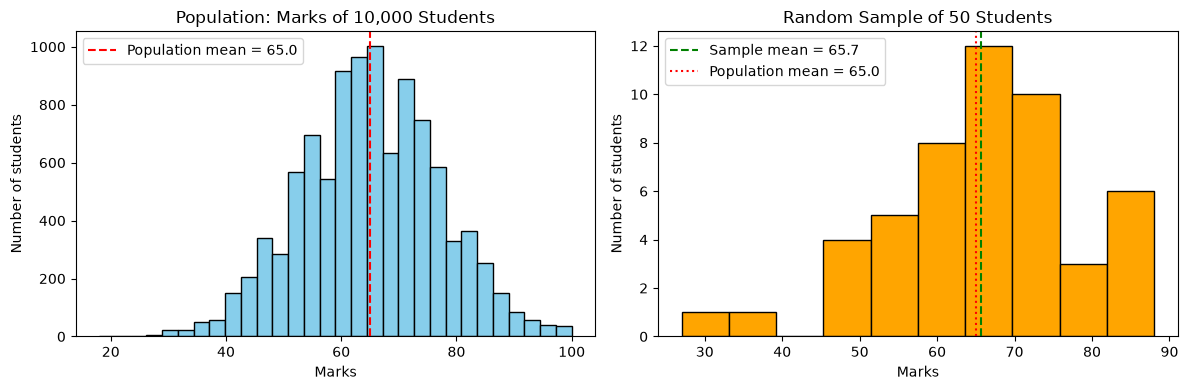

In [3]:
import numpy as np 
import matplotlib.pyplot as plt   
np.random.seed(42)          
population = np.random.normal(loc=65, scale=12, size=10000).round() 
population = np.clip(population, 0, 100)      
sample = np.random.choice(population, size=50, replace=False)   
print(f"  Population mean  (mu)    = {population.mean():.2f}") 
print(f"  Population SD    (sigma) = {population.std():.2f}") 
print("SAMPLE      (n = 50)") 
print(f"  Sample mean      (x-bar) = {sample.mean():.2f}") 
print(f"  Sample SD        (s)     = {sample.std(ddof=1):.2f}") 
print(f"Sampling error (x-bar - mu) = {sample.mean() - population.mean():.2f}")   
print("\nMeans of 5 different random samples of size 50:") 
for i in range(1, 6):     
    s = np.random.choice(population, size=50, replace=False)     
    print(f"  Sample {i}: mean = {s.mean():.2f}")   
fig, ax = plt.subplots(1, 2, figsize=(12, 4)) 
ax[0].hist(population, bins=30, color='skyblue', edgecolor='black') 
ax[0].axvline(population.mean(), color='red', linestyle='--', label=f'Population mean = {population.mean():.1f}') 
ax[0].set_title('Population: Marks of 10,000 Students') 
ax[0].set_xlabel('Marks'); 
ax[0].set_ylabel('Number of students'); 
ax[0].legend()   
ax[1].hist(sample, bins=10, color='orange', edgecolor='black') 
ax[1].axvline(sample.mean(), color='green', linestyle='--', label=f'Sample mean = {sample.mean():.1f}') 
ax[1].axvline(population.mean(), color='red', linestyle=':', label=f'Population mean = {population.mean():.1f}') 
ax[1].set_title('Random Sample of 50 Students') 
ax[1].set_xlabel('Marks'); 
ax[1].set_ylabel('Number of students'); 
ax[1].legend() 
plt.tight_layout() 
plt.show() 


Population mean = 40.04 min, Population SD = 7.99 min

    n   Mean of sample means    SE = σ/√n   SD of sample means
   10                  40.03         2.53                2.49
   30                  40.06         1.46                1.52
  100                  40.01         0.80                0.81


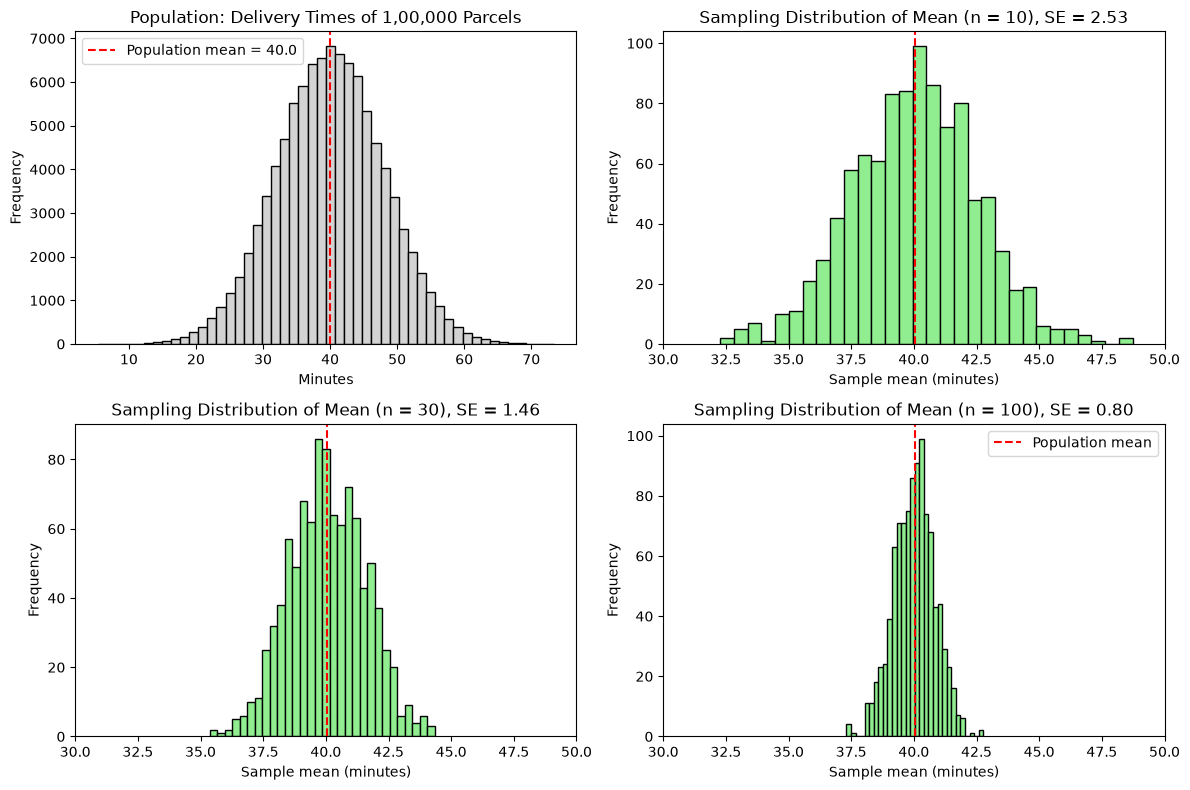


One sample of 30 parcels: mean = 39.50, estimated SE = s/√n = 1.28


In [5]:
import numpy as np
6
import matplotlib.pyplot as plt
np.random.seed(1)
# Step 1: Population of delivery times (minutes)
population = np.random.normal(loc=40, scale=8, size=100000)
mu, sigma = population.mean(), population.std()
print(f"Population mean = {mu:.2f} min, Population SD = {sigma:.2f} min\n")
# Step 2: Take 1000 samples for each sample size and store their means
sample_sizes = [10, 30, 100]
num_samples = 1000
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.ravel()
ax[0].hist(population, bins=50, color='lightgray', edgecolor='black')
ax[0].axvline(mu, color='red', linestyle='--', label=f'Population mean = {mu:.1f}')
ax[0].set_title('Population: Delivery Times of 1,00,000 Parcels')
ax[0].set_xlabel('Minutes'); ax[0].set_ylabel('Frequency'); ax[0].legend()
print(f"{'n':>5} {'Mean of sample means':>22} {'SE = σ/√n':>12} {'SD of sample means':>20}")
for i, n in enumerate(sample_sizes):
 sample_means = [np.random.choice(population, size=n, replace=False).mean() for _ in
range(num_samples)]
 se_formula = sigma / np.sqrt(n)
 se_observed = np.std(sample_means)
 print(f"{n:>5} {np.mean(sample_means):>22.2f} {se_formula:>12.2f}{se_observed:>20.2f}")
 ax[i+1].hist(sample_means, bins=30, color='lightgreen', edgecolor='black')
 ax[i+1].axvline(mu, color='red', linestyle='--', label='Population mean')
 ax[i+1].set_xlim(30, 50) # same scale so the spread can be compared
 ax[i+1].set_title(f'Sampling Distribution of Mean (n = {n}), SE = {se_formula:.2f}')
 ax[i+1].set_xlabel('Sample mean (minutes)'); ax[i+1].set_ylabel('Frequency');
ax[i+1].legend()
plt.tight_layout()
plt.show()
# Step 3: SE estimated from ONE sample of 30 parcels (sigma not known)
one_sample = np.random.choice(population, size=30, replace=False)
se_est = one_sample.std(ddof=1) / np.sqrt(30)
print(f"\nOne sample of 30 parcels: mean = {one_sample.mean():.2f}, estimated SE = s/√n = {se_est:.2f}")

Sample size (n) = 36
Sample mean (x-bar) = 496.67 g
Standard error = 1.3333
Z statistic = -2.5000
Critical value = ±1.96
p-value = 0.0124

Decision: |Z| > 1.96 -> Reject H0
Interpretation: The machine is NOT filling 500 g on average. It needsadjustment.


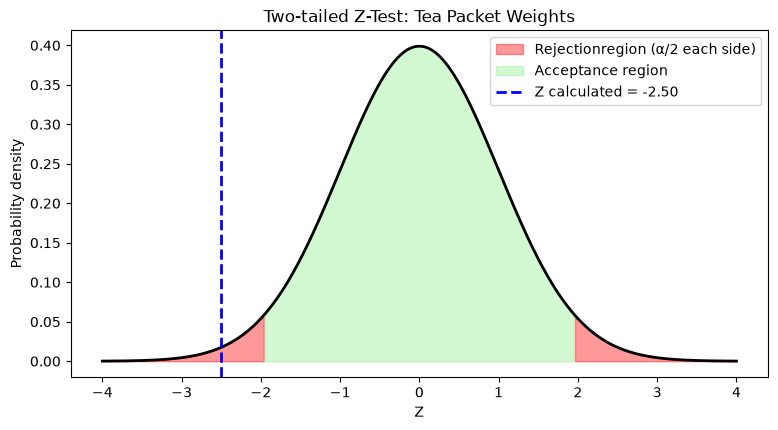

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
9
# Step 1: Data - weights (g) of 36 packets
weights = np.array([495, 498, 492, 501, 497, 494, 499, 496, 503, 490, 497, 500,
 493, 498, 495, 502, 491, 497, 499, 494, 496, 500, 492, 498,
 497, 495, 501, 493, 496, 499, 494, 498, 502, 495, 497, 496])
mu0 = 500 # claimed mean
sigma = 8 # known population SD
alpha = 0.05
n = len(weights)
x_bar = weights.mean()
# Step 2: Z statistic
se = sigma / np.sqrt(n)
z = (x_bar - mu0) / se
# Step 3: Critical value and p-value (two-tailed)
z_critical = stats.norm.ppf(1 - alpha/2)
p_value = 2 * (1 - stats.norm.cdf(abs(z)))
print(f"Sample size (n) = {n}")
print(f"Sample mean (x-bar) = {x_bar:.2f} g")
print(f"Standard error = {se:.4f}")
print(f"Z statistic = {z:.4f}")
print(f"Critical value = ±{z_critical:.2f}")
print(f"p-value = {p_value:.4f}")
# Step 4: Decision rule
if abs(z) > z_critical:
 print("\nDecision: |Z| > 1.96 -> Reject H0")
 print("Interpretation: The machine is NOT filling 500 g on average. It needsadjustment.")
else:
 print("\nDecision: |Z| <= 1.96 -> Fail to reject H0")
 print("Interpretation: The machine is filling 500 g on average.")
# Step 5: Graph - standard normal curve with rejection regions
x = np.linspace(-4, 4, 500)
y = stats.norm.pdf(x)
plt.figure(figsize=(9, 4.5))
plt.plot(x, y, 'k', lw=2)
plt.fill_between(x, y, where=(x <= -z_critical), color='red', alpha=0.4, label='Rejectionregion (α/2 each side)')
plt.fill_between(x, y, where=(x >= z_critical), color='red', alpha=0.4)
plt.fill_between(x, y, where=(abs(x) < z_critical), color='lightgreen', alpha=0.4,label='Acceptance region')
plt.axvline(z, color='blue', linestyle='--', lw=2, label=f'Z calculated = {z:.2f}')
plt.title('Two-tailed Z-Test: Tea Packet Weights')
plt.xlabel('Z'); plt.ylabel('Probability density'); plt.legend()
plt.show()


Z statistic = -1.7678

TWO-TAILED TEST (H1: mu != 1000)
 Critical values = ±1.960, p-value = 0.0771
 Decision: Fail to reject H0

LEFT-TAILED TEST (H1: mu < 1000)
 Critical value = -1.645, p-value = 0.0385
 Decision: Reject H0

RIGHT-TAILED TEST (H1: mu > 1000)
 Critical value = 1.645, p-value = 0.9615
 Decision: Fail to reject H0


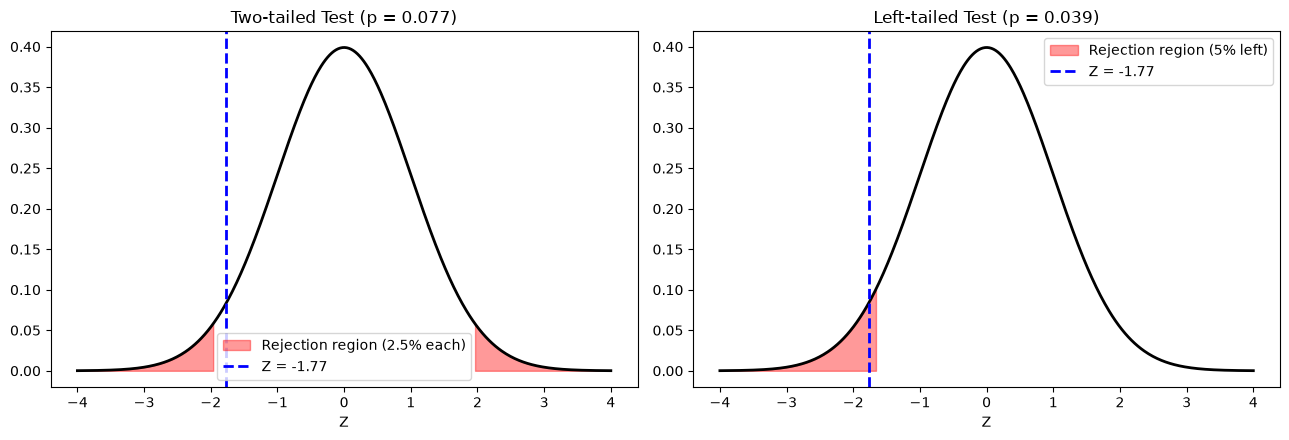

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
# Step 1: Given summary data
mu0 = 1000 # claimed mean life (hours)
sigma = 100 # population SD
n = 50
x_bar = 975
alpha = 0.05
12
# Step 2: Z statistic (same for both tests)
z = (x_bar - mu0) / (sigma / np.sqrt(n))
print(f"Z statistic = {z:.4f}\n")
# Step 3: Two-tailed test
z_crit_two = stats.norm.ppf(1 - alpha/2)
p_two = 2 * (1 - stats.norm.cdf(abs(z)))
print("TWO-TAILED TEST (H1: mu != 1000)")
print(f" Critical values = ±{z_crit_two:.3f}, p-value = {p_two:.4f}")
print(" Decision:", "Reject H0" if p_two < alpha else "Fail to reject H0")
# Step 4: Left-tailed test
z_crit_left = stats.norm.ppf(alpha)
p_left = stats.norm.cdf(z)
print("\nLEFT-TAILED TEST (H1: mu < 1000)")
print(f" Critical value = {z_crit_left:.3f}, p-value = {p_left:.4f}")
print(" Decision:", "Reject H0" if p_left < alpha else "Fail to reject H0")
# Step 5: Right-tailed (for comparison only)
p_right = 1 - stats.norm.cdf(z)
print("\nRIGHT-TAILED TEST (H1: mu > 1000)")
print(f" Critical value = {stats.norm.ppf(1-alpha):.3f}, p-value = {p_right:.4f}")
print(" Decision:", "Reject H0" if p_right < alpha else "Fail to reject H0")
# Step 6: Graph - two-tailed vs left-tailed rejection regions
x = np.linspace(-4, 4, 500)
y = stats.norm.pdf(x)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(x, y, 'k', lw=2)
ax[0].fill_between(x, y, where=(x <= -z_crit_two), color='red', alpha=0.4, label='Rejection region (2.5% each)')
ax[0].fill_between(x, y, where=(x >= z_crit_two), color='red', alpha=0.4)
ax[0].axvline(z, color='blue', linestyle='--', lw=2, label=f'Z = {z:.2f}')
ax[0].set_title(f'Two-tailed Test (p = {p_two:.3f})')
ax[0].set_xlabel('Z'); ax[0].legend()
ax[1].plot(x, y, 'k', lw=2)
ax[1].fill_between(x, y, where=(x <= z_crit_left), color='red', alpha=0.4, label='Rejection region (5% left)')
ax[1].axvline(z, color='blue', linestyle='--', lw=2, label=f'Z = {z:.2f}')
ax[1].set_title(f'Left-tailed Test (p = {p_left:.3f})')
ax[1].set_xlabel('Z'); ax[1].legend()
plt.tight_layout()
plt.show()

Sample mean = 5.760 min, Sample SD = 0.584
Degrees of freedom = 14
t statistic = 5.0395
t critical = ±2.1448
p-value = 0.000181

Decision: Reject H0 -> Average waiting time is significantly different from 5minutes.


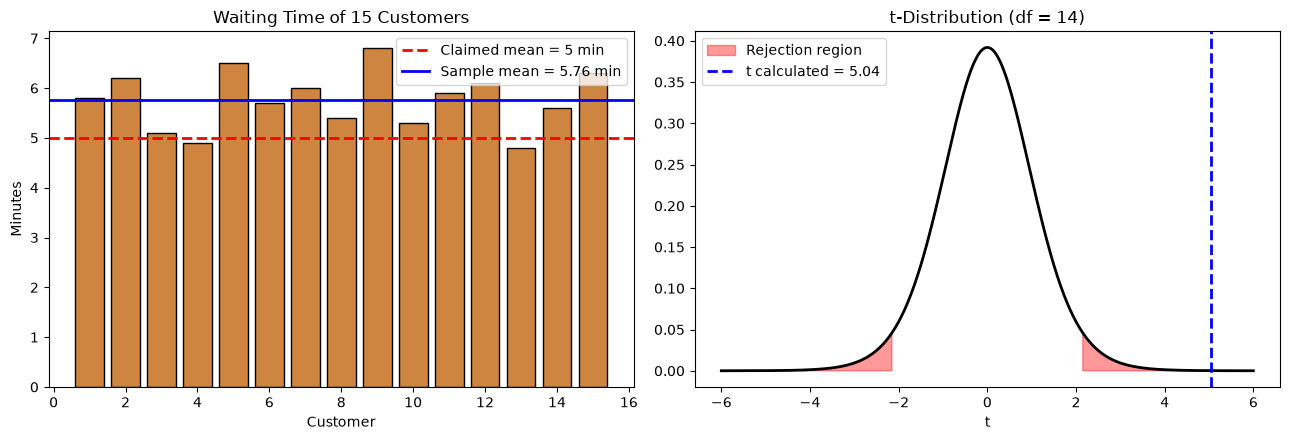

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
# Step 1: Data - waiting times (minutes) of 15 customers
wait = np.array([5.8, 6.2, 5.1, 4.9, 6.5, 5.7, 6.0, 5.4, 6.8, 5.3, 5.9, 6.1, 4.8, 5.6, 6.3])
mu0 = 5
alpha = 0.05
n = len(wait)
15
df = n - 1
# Step 2: t-test using scipy
t_stat, p_value = stats.ttest_1samp(wait, popmean=mu0)
t_critical = stats.t.ppf(1 - alpha/2, df)
print(f"Sample mean = {wait.mean():.3f} min, Sample SD = {wait.std(ddof=1):.3f}")
print(f"Degrees of freedom = {df}")
print(f"t statistic = {t_stat:.4f}")
print(f"t critical = ±{t_critical:.4f}")
print(f"p-value = {p_value:.6f}")
# Step 3: Decision
if p_value < alpha:
 print("\nDecision: Reject H0 -> Average waiting time is significantly different from 5minutes.")
else:
 print("\nDecision: Fail to reject H0 -> No significant difference from 5 minutes.")
# Step 4: Graphs
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(range(1, n+1), wait, color='peru', edgecolor='black')
ax[0].axhline(mu0, color='red', linestyle='--', lw=2, label='Claimed mean = 5 min')
ax[0].axhline(wait.mean(), color='blue', linestyle='-', lw=2, label=f'Sample mean = {wait.mean():.2f} min')
ax[0].set_title('Waiting Time of 15 Customers')
ax[0].set_xlabel('Customer'); ax[0].set_ylabel('Minutes'); ax[0].legend()
x = np.linspace(-6, 6, 500)
y = stats.t.pdf(x, df)
ax[1].plot(x, y, 'k', lw=2)
ax[1].fill_between(x, y, where=(abs(x) >= t_critical), color='red', alpha=0.4, label='Rejection region')
ax[1].axvline(t_stat, color='blue', linestyle='--', lw=2, label=f't calculated = {t_stat:.2f}')
ax[1].set_title(f't-Distribution (df = {df})')
ax[1].set_xlabel('t'); ax[1].legend()
plt.tight_layout()
plt.show()


Method A: mean = 67.08, SD = 3.60
Method B: mean = 75.83, SD = 3.33
Degrees of freedom = 22
t statistic = -6.1804
t critical = ±2.0739
p-value = 0.000003

Decision: Reject H0 -> The two teaching methods give significantly different marks.


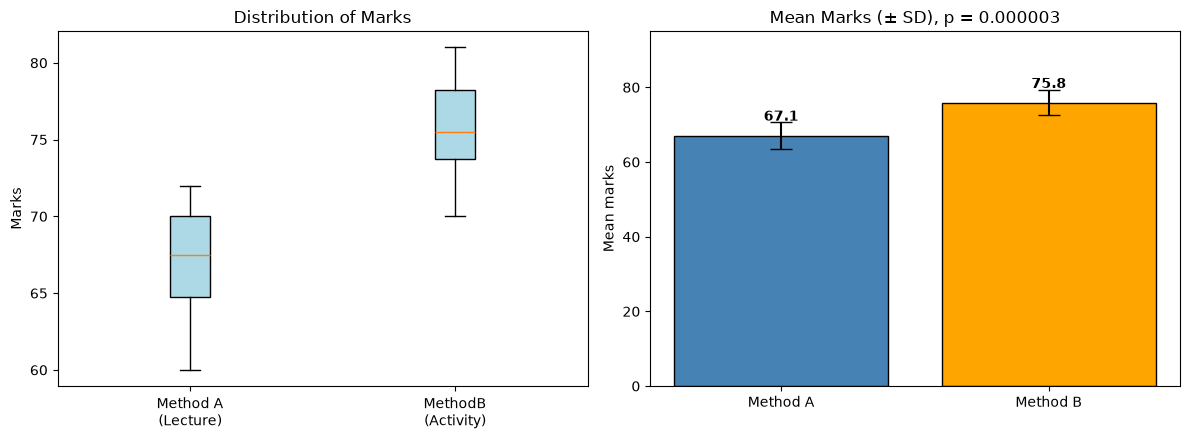

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
# Step 1: Data - marks of two different groups of students
method_A = np.array([65, 70, 68, 72, 60, 66, 69, 71, 64, 67, 63, 70]) # Lecture
method_B = np.array([72, 78, 75, 80, 74, 77, 79, 73, 76, 81, 70, 75]) # Activity-based
18
alpha = 0.05
# Step 2: Independent two-sample t-test (equal variances assumed)
t_stat, p_value = stats.ttest_ind(method_A, method_B, equal_var=True)
df = len(method_A) + len(method_B) - 2
t_critical = stats.t.ppf(1 - alpha/2, df)
print(f"Method A: mean = {method_A.mean():.2f}, SD = {method_A.std(ddof=1):.2f}")
print(f"Method B: mean = {method_B.mean():.2f}, SD = {method_B.std(ddof=1):.2f}")
print(f"Degrees of freedom = {df}")
print(f"t statistic = {t_stat:.4f}")
print(f"t critical = ±{t_critical:.4f}")
print(f"p-value = {p_value:.6f}")
# Step 3: Decision
if p_value < alpha:
 print("\nDecision: Reject H0 -> The two teaching methods give significantly different marks.")
else:
 print("\nDecision: Fail to reject H0 -> No significant difference between the methods.")
# Step 4: Graphs - boxplot and mean bar chart
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].boxplot([method_A, method_B], patch_artist=True,
boxprops=dict(facecolor='lightblue'))
ax[0].set_xticks([1, 2]); ax[0].set_xticklabels(['Method A\n(Lecture)', 'MethodB\n(Activity)'])
ax[0].set_title('Distribution of Marks'); ax[0].set_ylabel('Marks')
means = [method_A.mean(), method_B.mean()]
errors = [method_A.std(ddof=1), method_B.std(ddof=1)]
ax[1].bar(['Method A', 'Method B'], means, yerr=errors, capsize=8, color=['steelblue','orange'], edgecolor='black')
for i, m in enumerate(means):
 ax[1].text(i, m + 4, f'{m:.1f}', ha='center', fontweight='bold')
ax[1].set_title(f'Mean Marks (± SD), p = {p_value:.6f}'); ax[1].set_ylabel('Mean marks')
ax[1].set_ylim(0, 95)
plt.tight_layout()
plt.show()

Differences (Before - After): [8 5 9 5 3 6 8 2 9 6]
Mean difference = 6.10 mmHg, SD of differences =2.42
t statistic = 7.9565
t critical = 1.8331 (one-tailed, df = 9)
p-value = 0.000012

Decision: Reject H0 -> Yoga significantly reduced blood pressure.


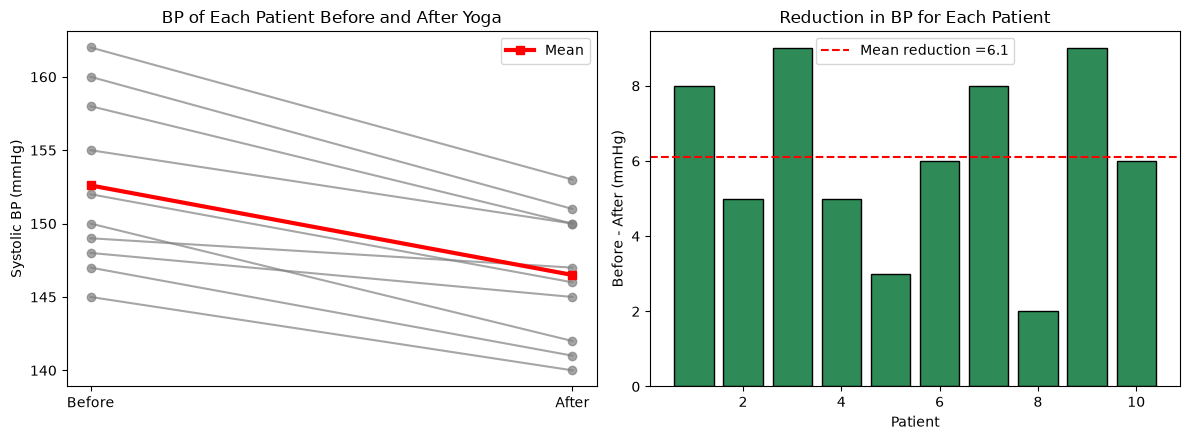

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
# Step 1: Data - BP of the same 10 patients
before = np.array([150, 145, 160, 155, 148, 152, 158, 149, 162, 147])
after = np.array([142, 140, 151, 150, 145, 146, 150, 147, 153, 141])
diff = before - after
alpha = 0.05
n = len(diff)
# Step 2: Paired t-test (one-tailed: before > after)
21
t_stat, p_value = stats.ttest_rel(before, after, alternative='greater')
t_critical = stats.t.ppf(1 - alpha, n - 1)
print("Differences (Before - After):", diff)
print(f"Mean difference = {diff.mean():.2f} mmHg, SD of differences ={diff.std(ddof=1):.2f}")
print(f"t statistic = {t_stat:.4f}")
print(f"t critical = {t_critical:.4f} (one-tailed, df = {n-1})")
print(f"p-value = {p_value:.6f}")
# Step 3: Decision
if p_value < alpha:
 print("\nDecision: Reject H0 -> Yoga significantly reduced blood pressure.")
else:
 print("\nDecision: Fail to reject H0 -> No significant reduction in blood pressure.")
# Step 4: Graphs
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for i in range(n):
 ax[0].plot(['Before', 'After'], [before[i], after[i]], marker='o', color='gray', alpha=0.7)
ax[0].plot(['Before', 'After'], [before.mean(), after.mean()], marker='s', color='red', lw=3,label='Mean')
ax[0].set_title('BP of Each Patient Before and After Yoga')
ax[0].set_ylabel('Systolic BP (mmHg)'); ax[0].legend()
ax[1].bar(range(1, n+1), diff, color='seagreen', edgecolor='black')
ax[1].axhline(diff.mean(), color='red', linestyle='--', label=f'Mean reduction ={diff.mean():.1f}')
ax[1].set_title('Reduction in BP for Each Patient')
ax[1].set_xlabel('Patient'); ax[1].set_ylabel('Before - After (mmHg)'); ax[1].legend()
plt.tight_layout()
plt.show()

Variance of Machine A = 0.1210
Variance of Machine B = 0.0090
F statistic = 13.4444 (df1 = 9, df2 = -114)
F critical = nan
p-value = nan

Decision: Fail to reject H0 -> Both machines have similar variability.


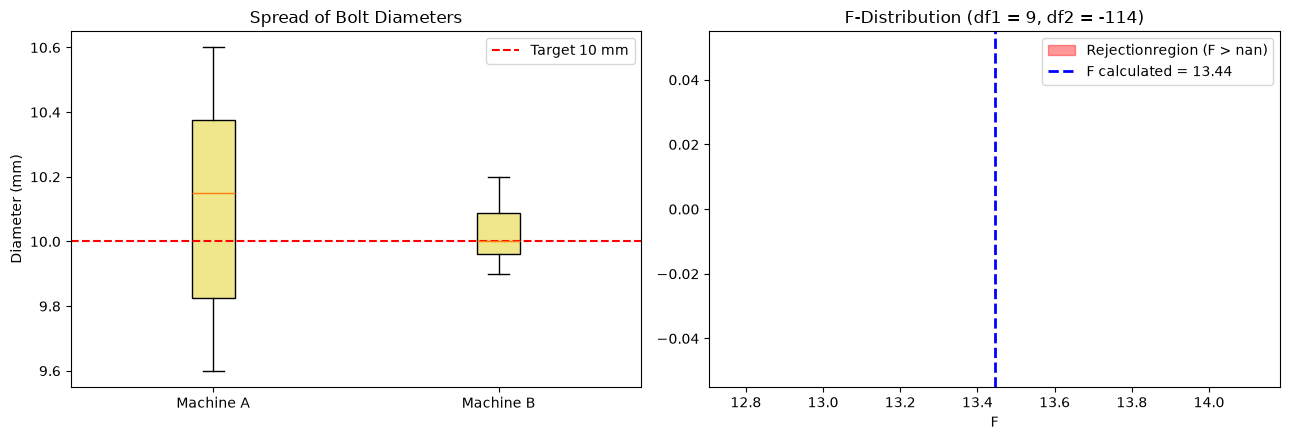

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
# Step 1: Data - bolt diameters (mm)
machine_A = np.array([10.2, 9.8, 10.5, 9.6, 10.4, 9.9, 10.6, 9.7, 10.3, 10.1])
machine_B = np.array([10.0, 10.1, 9.9, 10.0, 10.2, 9.95, 10.05, 10.1, 9.9, 10.0])
alpha = 0.05
# Step 2: Sample variances
var_A = np.var(machine_A, ddof=1)
var_B = np.var(machine_B, ddof=1)
# Step 3: F statistic (larger variance / smaller variance)
if var_A >= var_B:
 F = var_A / var_B
 df1, df2 = len(machine_A) - 1, len(machine_B) - 124
else:
 F = var_B / var_A
 df1, df2 = len(machine_B) - 1, len(machine_A) - 1
p_value = 2 * (1 - stats.f.cdf(F, df1, df2)) # two-tailed
F_critical = stats.f.ppf(1 - alpha/2, df1, df2)
print(f"Variance of Machine A = {var_A:.4f}")
print(f"Variance of Machine B = {var_B:.4f}")
print(f"F statistic = {F:.4f} (df1 = {df1}, df2 = {df2})")
print(f"F critical = {F_critical:.4f}")
print(f"p-value = {p_value:.6f}")
# Step 4: Decision
if F > F_critical:
 print("\nDecision: Reject H0 -> The variances are different. Machine A is lessconsistent.")
else:
 print("\nDecision: Fail to reject H0 -> Both machines have similar variability.")
# Step 5: Graphs
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].boxplot([machine_A, machine_B], patch_artist=True,
boxprops=dict(facecolor='khaki'))
ax[0].set_xticks([1, 2]); ax[0].set_xticklabels(['Machine A', 'Machine B'])
ax[0].axhline(10, color='red', linestyle='--', label='Target 10 mm')
ax[0].set_title('Spread of Bolt Diameters'); ax[0].set_ylabel('Diameter (mm)');
ax[0].legend()
x = np.linspace(0.01, max(F + 5, 8), 500)
y = stats.f.pdf(x, df1, df2)
ax[1].plot(x, y, 'k', lw=2)
ax[1].fill_between(x, y, where=(x >= F_critical), color='red', alpha=0.4, label=f'Rejectionregion (F > {F_critical:.2f})')
ax[1].axvline(F, color='blue', linestyle='--', lw=2, label=f'F calculated = {F:.2f}')
ax[1].set_title(f'F-Distribution (df1 = {df1}, df2 = {df2})')
ax[1].set_xlabel('F'); ax[1].legend()
plt.tight_layout()
plt.show()


ONE-WAY ANOVA TABLE
Source                  SS    df        MS         F
Between groups       62.40     2     31.20    12.480
Within groups        30.00    12      2.50
Total                92.40    14

F critical = 3.885, p-value = 0.001171
scipy f_oneway: F = 12.480, p = 0.001171
 Mean yield of Fertilizer A = 21.20
 Mean yield of Fertilizer B = 26.00
 Mean yield of Fertilizer C = 22.40

Decision: Reject H0 -> At least one fertilizer gives a different average yield.


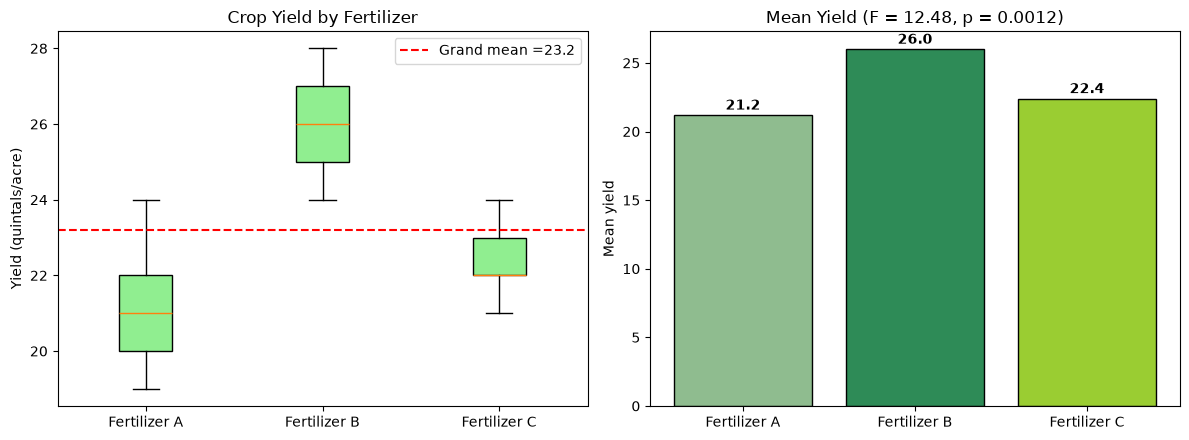

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
# Step 1: Data - yield (quintals/acre)
fert_A = np.array([20, 22, 19, 24, 21])
fert_B = np.array([25, 27, 24, 26, 28])
fert_C = np.array([22, 23, 21, 24, 22])
groups = [fert_A, fert_B, fert_C]
names = ['Fertilizer A', 'Fertilizer B', 'Fertilizer C']
alpha = 0.05
# Step 2: ANOVA table calculated step by step
27
all_data = np.concatenate(groups)
grand_mean = all_data.mean()
k, N = len(groups), len(all_data)
SSB = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups) # between groups
SSW = sum(((g - g.mean())**2).sum() for g in groups) # within groups
SST = SSB + SSW
df_b, df_w = k - 1, N - k
MSB, MSW = SSB / df_b, SSW / df_w
F = MSB / MSW
p_value = 1 - stats.f.cdf(F, df_b, df_w)
F_critical = stats.f.ppf(1 - alpha, df_b, df_w)
print("ONE-WAY ANOVA TABLE")
print(f"{'Source':<16}{'SS':>10}{'df':>6}{'MS':>10}{'F':>10}")
print(f"{'Between groups':<16}{SSB:>10.2f}{df_b:>6}{MSB:>10.2f}{F:>10.3f}")
print(f"{'Within groups':<16}{SSW:>10.2f}{df_w:>6}{MSW:>10.2f}")
print(f"{'Total':<16}{SST:>10.2f}{N-1:>6}")
print(f"\nF critical = {F_critical:.3f}, p-value = {p_value:.6f}")
# Step 3: Check with scipy
F_scipy, p_scipy = stats.f_oneway(fert_A, fert_B, fert_C)
print(f"scipy f_oneway: F = {F_scipy:.3f}, p = {p_scipy:.6f}")
# Step 4: Decision
for name, g in zip(names, groups):
 print(f" Mean yield of {name} = {g.mean():.2f}")
if p_value < alpha:
 print("\nDecision: Reject H0 -> At least one fertilizer gives a different average yield.")
else:
 print("\nDecision: Fail to reject H0 -> All fertilizers give the same average yield.")
# Step 5: Graph
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].boxplot(groups, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
ax[0].set_xticks([1, 2, 3]); ax[0].set_xticklabels(names)
ax[0].axhline(grand_mean, color='red', linestyle='--', label=f'Grand mean ={grand_mean:.1f}')
ax[0].set_title('Crop Yield by Fertilizer'); ax[0].set_ylabel('Yield (quintals/acre)');
ax[0].legend()
means = [g.mean() for g in groups]
ax[1].bar(names, means, color=['#8fbc8f', '#2e8b57', '#9acd32'], edgecolor='black')
for i, m in enumerate(means):
 ax[1].text(i, m + 0.4, f'{m:.1f}', ha='center', fontweight='bold')
ax[1].set_title(f'Mean Yield (F = {F:.2f}, p = {p_value:.4f})'); ax[1].set_ylabel('Mean yield')
plt.tight_layout()
plt.show()

Irrigation  High   Low
Fertilizer            
A           26.0  21.0
B           30.0  24.0
C           33.0  22.0

TWO-WAY ANOVA TABLE
                             sum_sq    df      F  PR(>F)
C(Fertilizer)                  57.0   2.0   28.5  0.0000
C(Irrigation)                 242.0   1.0  242.0  0.0000
C(Fertilizer):C(Irrigation)    31.0   2.0   15.5  0.0005
Residual                       12.0  12.0    NaN     NaN

C(Fertilizer)                  p = 0.000028 -> Significant (Reject H0)
C(Irrigation)                  p = 0.000000 -> Significant (Reject H0)
C(Fertilizer):C(Irrigation)    p = 0.000472 -> Significant (Reject H0)


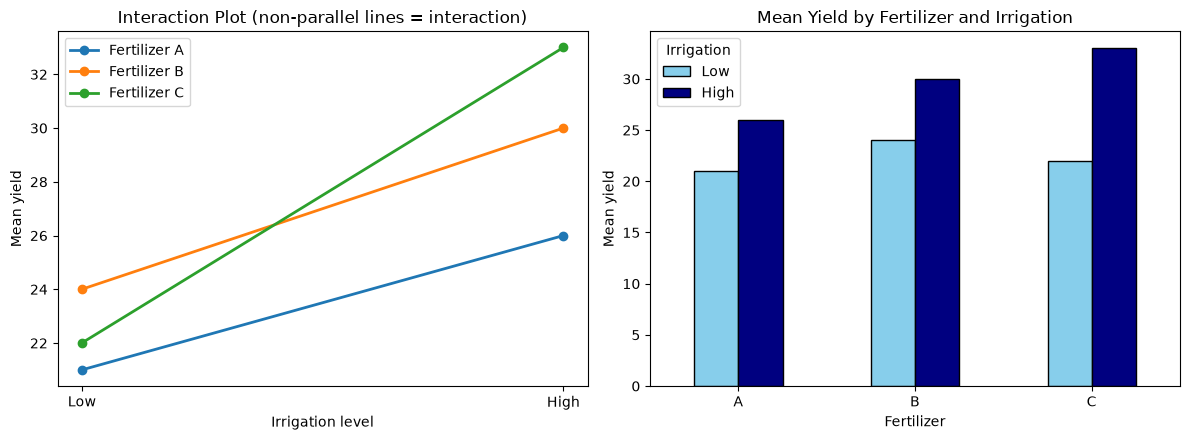

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
# Step 1: Data in table form
data = pd.DataFrame({'Fertilizer': ['A']*6 + ['B']*6 + ['C']*6,'Irrigation': (['Low']*3 + ['High']*3) * 3,
                     'Yield': [20, 22, 21, 25, 27, 26, # Fertilizer A 
                                                                                                                
                               24, 25, 23, 30, 31, 29, # Fertilizer B
                                                                                                                    
                               22, 21, 23, 32, 33, 34] # Fertilizer C 
                    })
print(data.pivot_table(values='Yield', index='Fertilizer', columns='Irrigation',
aggfunc='mean').round(2))
alpha = 0.05
# Step 2: Two-way ANOVA with interaction
model = ols('Yield ~ C(Fertilizer) + C(Irrigation) + C(Fertilizer):C(Irrigation)',
data=data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("\nTWO-WAY ANOVA TABLE")
print(anova_table.round(4))
# Step 3: Decision for each factor
print()
for source in anova_table.index[:-1]:
 p = anova_table.loc[source, 'PR(>F)']
 decision = 'Significant (Reject H0)' if p < alpha else 'Not significant (Fail to reject H0)'
 print(f"{source:<30} p = {p:.6f} -> {decision}")
# Step 4: Graphs - interaction plot and grouped bar chart
means = data.groupby(['Fertilizer', 'Irrigation'])['Yield'].mean().unstack()[['Low', 'High']]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for fert in means.index:
 ax[0].plot(means.columns, means.loc[fert], marker='o', lw=2, label=f'Fertilizer {fert}')
ax[0].set_title('Interaction Plot (non-parallel lines = interaction)')
ax[0].set_xlabel('Irrigation level'); ax[0].set_ylabel('Mean yield'); ax[0].legend()
means.plot(kind='bar', ax=ax[1], color=['skyblue', 'navy'], edgecolor='black', rot=0)
ax[1].set_title('Mean Yield by Fertilizer and Irrigation')
ax[1].set_xlabel('Fertilizer'); ax[1].set_ylabel('Mean yield')
plt.tight_layout()
plt.show()

 Face     O       E   (O-E)^2/E
    1    25    20.0       1.250
    2    17    20.0       0.450
    3    15    20.0       1.250
    4    23    20.0       0.450
    5    24    20.0       0.800
    6    16    20.0       0.800

Chi-square statistic = 5.0000
Degrees of freedom = 5
Chi-square critical = 11.0705
p-value = 0.4159

Decision: Fail to reject H0 -> The die is fair; differences are due to chance.


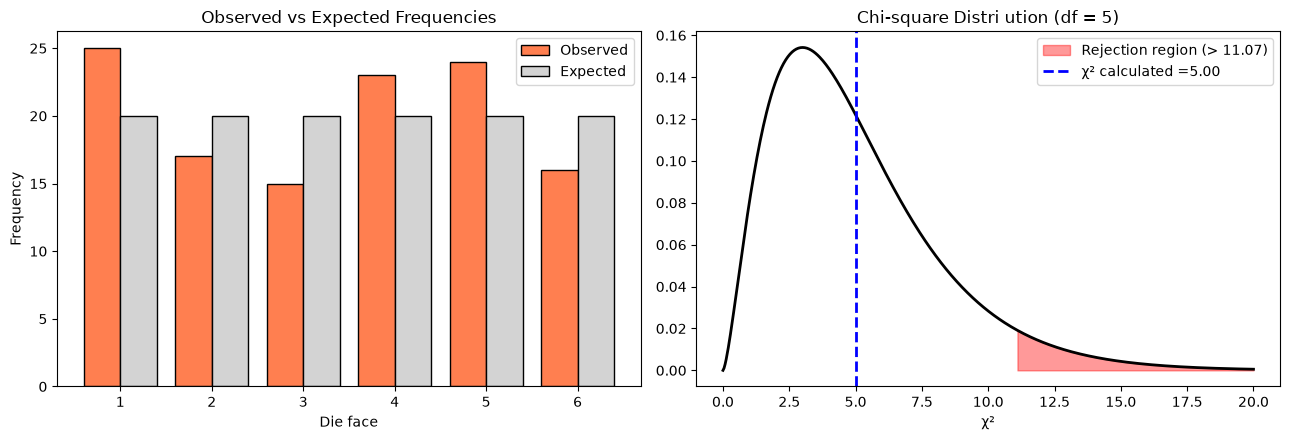

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
# Step 1: Data
faces = ['1', '2', '3', '4', '5', '6']
observed = np.array([25, 17, 15, 23, 24, 16])
expected = np.array([sum(observed) / 6] * 6)
alpha = 0.05
# Step 2: Calculation table
print(f"{'Face':>5}{'O':>6}{'E':>8}{'(O-E)^2/E':>12}")
for f, o, e in zip(faces, observed, expected):
 print(f"{f:>5}{o:>6}{e:>8.1f}{(o-e)**2/e:>12.3f}")
33
# Step 3: Chi-square test
chi2_stat, p_value = stats.chisquare(f_obs=observed, f_exp=expected)
df = len(observed) - 1
chi2_critical = stats.chi2.ppf(1 - alpha, df)
print(f"\nChi-square statistic = {chi2_stat:.4f}")
print(f"Degrees of freedom = {df}")
print(f"Chi-square critical = {chi2_critical:.4f}")
print(f"p-value = {p_value:.4f}")
# Step 4: Decision
if p_value < alpha:
 print("\nDecision: Reject H0 -> The die is biased.")
else:
 print("\nDecision: Fail to reject H0 -> The die is fair; differences are due to chance.")
# Step 5: Graphs
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(6)
ax[0].bar(x - 0.2, observed, width=0.4, label='Observed', color='coral', edgecolor='black')
ax[0].bar(x + 0.2, expected, width=0.4, label='Expected', color='lightgray',edgecolor='black')
ax[0].set_xticks(x); ax[0].set_xticklabels(faces)
ax[0].set_title('Observed vs Expected Frequencies'); ax[0].set_xlabel('Die face');
ax[0].set_ylabel('Frequency')
ax[0].legend()
xc = np.linspace(0, 20, 500)
yc = stats.chi2.pdf(xc, df)
ax[1].plot(xc, yc, 'k', lw=2)
ax[1].fill_between(xc, yc, where=(xc >= chi2_critical), color='red', alpha=0.4,label=f'Rejection region (> {chi2_critical:.2f})')
ax[1].axvline(chi2_stat, color='blue', linestyle='--', lw=2, label=f'χ² calculated ={chi2_stat:.2f}')
ax[1].set_title(f'Chi-square Distri ution (df = {df})'); ax[1].set_xlabel('χ²'); ax[1].legend()
plt.tight_layout()
plt.show()


Observed frequencies:
        Online  Offline  Hybrid
Male        30       45      25
Female      50       25      25

Expected frequencies:
        Online  Offline  Hybrid
Male      40.0     35.0    25.0
Female    40.0     35.0    25.0

Chi-square statistic = 10.7143
Degrees of freedom = 2
Chi-square critical = 5.9915
p-value = 0.004714

Decision: Reject H0 -> Learning-mode preference depends on gender.


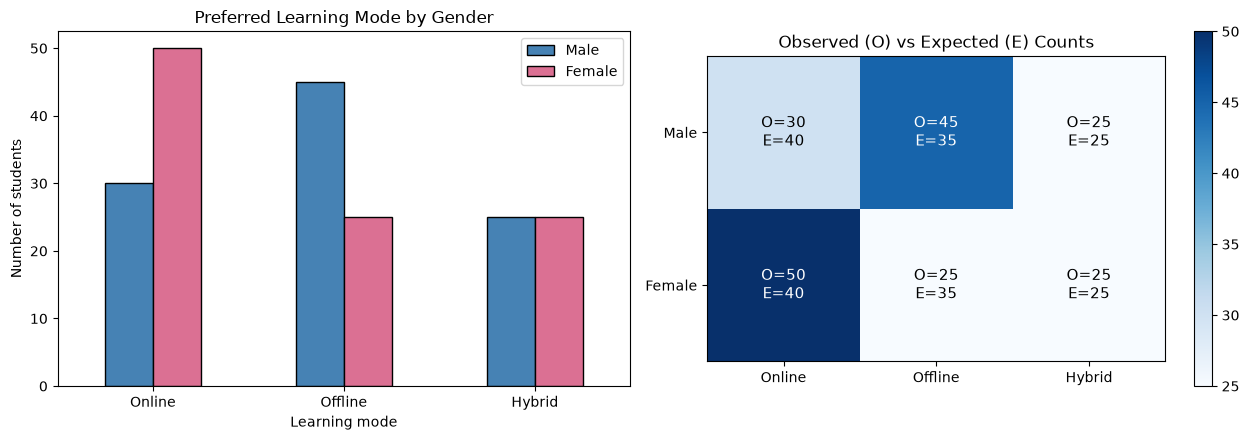

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Step 1: Contingency table
table = pd.DataFrame([[30, 45, 25],
                      [50, 25, 25]],
                     index=['Male', 'Female'],
                     columns=['Online', 'Offline', 'Hybrid'])
print("Observed frequencies:")
print(table)

alpha = 0.05

# Step 2: Chi-square test of independence
chi2_stat, p_value, df, expected = stats.chi2_contingency(table)

print("\nExpected frequencies:")
print(pd.DataFrame(expected, index=table.index, columns=table.columns).round(2))

chi2_critical = stats.chi2.ppf(1 - alpha, df)
print(f"\nChi-square statistic = {chi2_stat:.4f}")
print(f"Degrees of freedom = {df}")
print(f"Chi-square critical = {chi2_critical:.4f}")
print(f"p-value = {p_value:.6f}")

# Step 3: Decision
if p_value < alpha:
    print("\nDecision: Reject H0 -> Learning-mode preference depends on gender.")
else:
    print("\nDecision: Fail to reject H0 -> Learning-mode preference is independent of gender.")

# Step 4: Graphs
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

table.T.plot(kind='bar', ax=ax[0], color=['steelblue', 'palevioletred'],
             edgecolor='black', rot=0)
ax[0].set_title('Preferred Learning Mode by Gender')
ax[0].set_xlabel('Learning mode')
ax[0].set_ylabel('Number of students')

im = ax[1].imshow(table.values, cmap='Blues')
ax[1].set_xticks(range(3))
ax[1].set_xticklabels(table.columns)
ax[1].set_yticks(range(2))
ax[1].set_yticklabels(table.index)

for i in range(2):
    for j in range(3):
        color = 'white' if table.values[i, j] > 40 else 'black'
        ax[1].text(j, i, f'O={table.values[i, j]}\nE={expected[i, j]:.0f}',
                   ha='center', va='center', fontsize=11, color=color)

ax[1].set_title('Observed (O) vs Expected (E) Counts')
plt.colorbar(im, ax=ax[1])
plt.tight_layout()
plt.show()